In [1]:
import data_points

import pickle
import pathlib

import numpy as np
import plotly.express as px
import plotly.io as pio

pio.templates.default = 'plotly_white'

In [2]:
p = pathlib.Path("points-scikit.dat")
model = pickle.loads(p.read_bytes())

In [3]:
print(len(model.loss_curve_))
print(np.max(model.loss_curve_))
print(np.min(model.loss_curve_))

25
3.201830968272242
0.05234938341872693


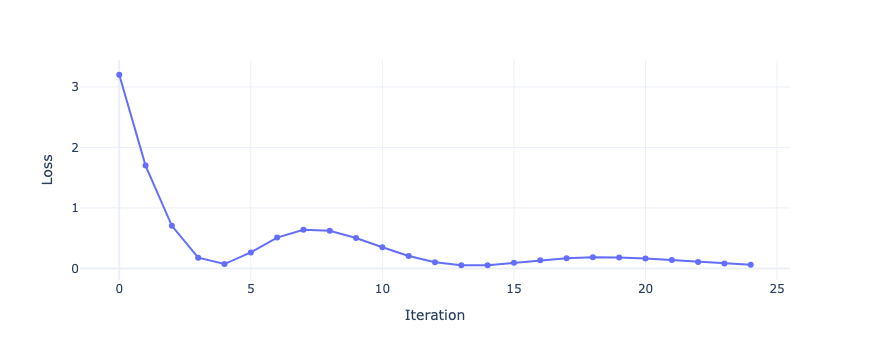

In [4]:
px.line(y=model.loss_curve_, markers=True, 
        labels={'x': "Iteration", 'y': 'Loss'})

In [5]:
last = model.loss_curve_[-1]
min_idx = np.argmin(model.loss_curve_)
min_loss = model.loss_curve_[min_idx]
print(f"last loss = {last:.7f}, min_idx={min_idx}, "
      f"min loss={min_loss:.7f}")

last loss = 0.0589091, min_idx=13, min loss=0.0523494


In [10]:
x, y = data_points.get_points()
pred_y = model.predict(np.expand_dims(x, -1))
mse = data_points.calc_mse(pred_y, y)
mae = data_points.calc_mae(pred_y, y)
print(f"MSE = {mse:.6f}, MAE = {mae:.6f}")

MSE = 0.096125, MAE = 0.272422


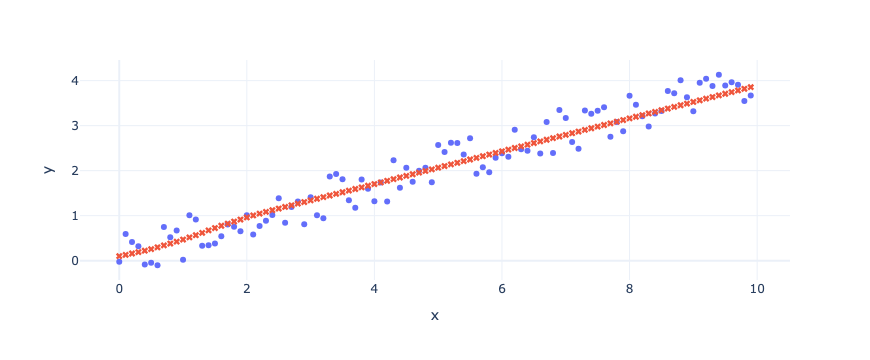

In [7]:
f = px.scatter(x=x, y=y)
f.add_scatter(x=x, y=pred_y, showlegend=False, 
              mode='markers', marker_symbol='x')

MSE = 0.222034, MAE = 0.380654


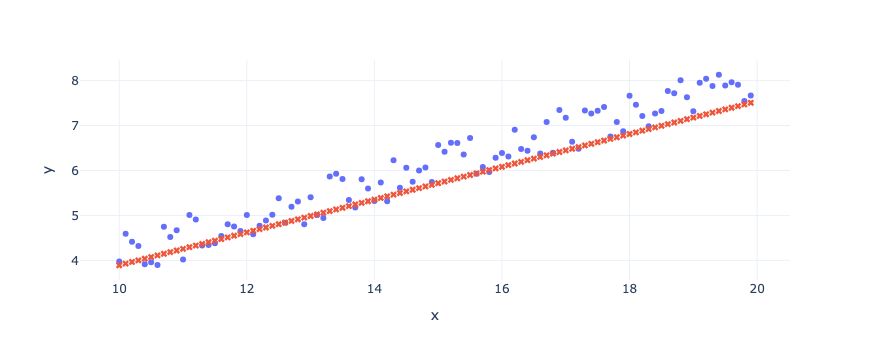

In [12]:
x, y = data_points.get_points(min_x=10, max_x=20)
pred_y = model.predict(np.expand_dims(x, -1))
mse = data_points.calc_mse(pred_y, y)
mae = data_points.calc_mae(pred_y, y)
print(f"MSE = {mse:.6f}, MAE = {mae:.6f}")

f = px.scatter(x=x, y=y)
f.add_scatter(x=x, y=pred_y, showlegend=False, 
              mode='markers', marker_symbol='x')

MSE = 1.302879, MAE = 0.960558


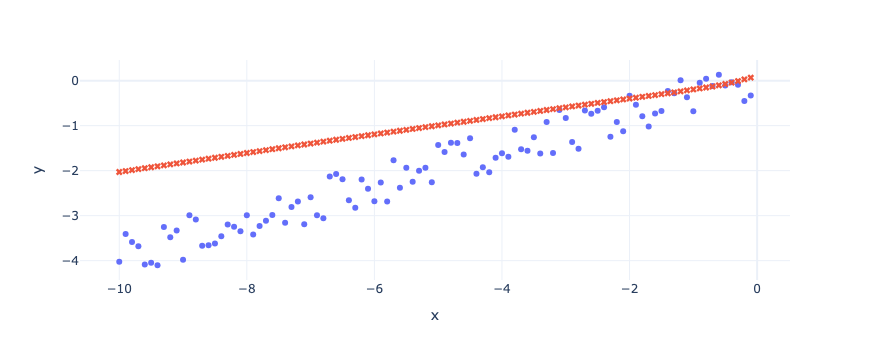

In [13]:
x, y = data_points.get_points(min_x=-10, max_x=0)
pred_y = model.predict(np.expand_dims(x, -1))
mse = data_points.calc_mse(pred_y, y)
mae = data_points.calc_mae(pred_y, y)
print(f"MSE = {mse:.6f}, MAE = {mae:.6f}")

f = px.scatter(x=x, y=y)
f.add_scatter(x=x, y=pred_y, showlegend=False, 
              mode='markers', marker_symbol='x')